In [4]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [5]:
print(df[['Survived', 'Pclass', 'Age', 'Fare', 'SibSp', 'Parch']].corr())

          Survived    Pclass       Age      Fare     SibSp     Parch
Survived  1.000000 -0.338481 -0.077221  0.257307 -0.035322  0.081629
Pclass   -0.338481  1.000000 -0.369226 -0.549500  0.083081  0.018443
Age      -0.077221 -0.369226  1.000000  0.096067 -0.308247 -0.189119
Fare      0.257307 -0.549500  0.096067  1.000000  0.159651  0.216225
SibSp    -0.035322  0.083081 -0.308247  0.159651  1.000000  0.414838
Parch     0.081629  0.018443 -0.189119  0.216225  0.414838  1.000000


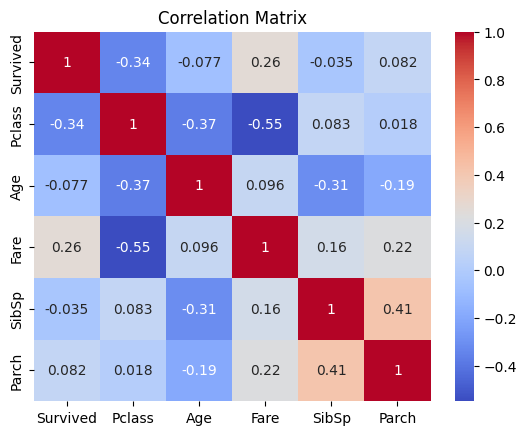

In [14]:
import seaborn as sns
sns.heatmap(df[['Survived','Pclass','Age','Fare','SibSp','Parch']].corr(), 
             annot=True,cmap='coolwarm') #'viridis', 'RdYlGn', 'Blues'
plt.title('Correlation Matrix')
plt.show()

In [15]:
print(df.duplicated().sum())
# df = df.drop_duplicates()

0


In [16]:
df = df.rename(columns={'SibSp': 'Siblings_Spouses', 'Parch': 'Parents_Children'})
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age',
       'Siblings_Spouses', 'Parents_Children', 'Ticket', 'Fare', 'Cabin',
       'Embarked'],
      dtype='object')


In [17]:
df['Family_Size'] = df['Siblings_Spouses'] + df['Parents_Children'] + 1
print(df['Family_Size'].value_counts())

Family_Size
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64


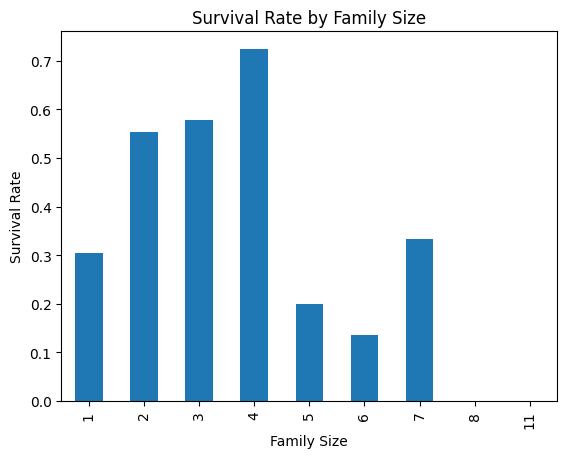

In [18]:
df.groupby('Family_Size')['Survived'].mean().plot(kind='bar')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Family Size')
plt.show()

In [21]:
print(df['Pclass'].value_counts(normalize=True))

Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64


In [22]:
print(df['Sex'].describe())
print(df['Embarked'].describe())

count      891
unique       2
top       male
freq       577
Name: Sex, dtype: object
count     889
unique      3
top         S
freq      644
Name: Embarked, dtype: object


In [23]:
print(df['Embarked'].unique())    # what unique values exist
print(df['Embarked'].nunique())   # how many unique values

['S' 'C' 'Q' nan]
3


In [24]:
# Survived AND (1st class OR female)
filtered = df[(df['Survived'] == 1) & ((df['Pclass'] == 1) | (df['Sex'] == 'female'))]
print(filtered.shape)

(278, 13)


In [26]:
df['Age_group'] = pd.cut(df['Age'], bins=[0,18,35,60,100], labels=['Child','Young','Middle','Senior'])
print(df.groupby('Age_group', observed=True)['Survived'].mean())

Age_group
Child     0.503597
Young     0.382682
Middle    0.400000
Senior    0.227273
Name: Survived, dtype: float64


In [27]:
print(pd.crosstab(df['Sex'], df['Pclass']))
print(pd.crosstab(df['Sex'], df['Pclass'], values=df['Survived'], aggfunc='mean'))

Pclass    1    2    3
Sex                  
female   94   76  144
male    122  108  347
Pclass         1         2         3
Sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447
